## Bayesian Network for Breast Cancer Diagnosis

**Objective**

To compute posterior probability:

$$
P(D \mid X_1, X_2, X_3, X_4)
$$

using Bayesian Networks.

Mathematical Foundation

Bayes’ Theorem:

$$
P(D \mid T) = \frac{P(T \mid D)\, P(D)}{P(T)}
$$

Likelihood ratio form:

$$
P(D \mid T) \propto \frac{P(T \mid D)}{P(T \mid \neg D)} \cdot P(D)
$$

Connection to Theory

Forward probability: $P(T \mid D)$  

Inverse probability: $P(D \mid T)$  

This implementation computes inverse probability using multiple evidences.

In [ ]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import classification_report
import networkx as nx
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Data Model

Dataset:

$$
\mathcal{D} = \{(d^{(i)}, x_1^{(i)}, x_2^{(i)}, x_3^{(i)}, x_4^{(i)})\}
$$

Assumption:

$$
(d,x) \sim P(D,X)
$$

Samples are independent and identically distributed.

In [ ]:
# data = pd.read_csv('/content/drive/MyDrive/data.csv')
data = pd.read_csv('/content/data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Discretization

Continuous variables:

$$
p(x \mid D)
$$

are transformed into:

$$
P(X \mid D), \quad X \in \{Low, High\}
$$

Rule:

$$
X =
\begin{cases}
Low & x \leq median \\
High & x > median
\end{cases}
$$

In [ ]:
features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean']

for f in features:
    data[f + '_discrete'] = pd.qcut(data[f], q=2, labels=['Low', 'High'])

df_bn = data[['diagnosis', 'radius_mean_discrete', 'texture_mean_discrete',
              'smoothness_mean_discrete', 'concavity_mean_discrete']]

df_bn.head()

,diagnosis,radius_mean_discrete,texture_mean_discrete,smoothness_mean_discrete,concavity_mean_discrete
0,M,High,Low,High,High
1,M,High,Low,Low,High
2,M,High,High,High,High
3,M,Low,High,High,High
4,M,High,Low,High,High


Bayesian Network Structure

$$
D \rightarrow X_1, X_2, X_3
$$

$$
X_1 \rightarrow X_4
$$

Joint distribution:

$$
P(D,X_1,X_2,X_3,X_4)
= P(D)P(X_1|D)P(X_2|D)P(X_3|D)P(X_4|X_1)
$$

In [ ]:
model = DiscreteBayesianNetwork([
    ('diagnosis', 'radius_mean_discrete'),
    ('diagnosis', 'texture_mean_discrete'),
    ('diagnosis', 'smoothness_mean_discrete'),
    ('radius_mean_discrete', 'concavity_mean_discrete')
])

Parameter Estimation

$$
\hat{P}(X=x \mid Pa(X)=u)
= \frac{N(x,u)}{N(u)}
$$

In [ ]:
model.fit(df_bn, estimator=MaximumLikelihoodEstimator)

print(model.get_cpds('radius_mean_discrete'))

+----------------------------+---------------------+---------------------+
| diagnosis                  | diagnosis(B)        | diagnosis(M)        |
+----------------------------+---------------------+---------------------+
| radius_mean_discrete(High) | 0.24929971988795518 | 0.9198113207547169  |
+----------------------------+---------------------+---------------------+
| radius_mean_discrete(Low)  | 0.7507002801120448  | 0.08018867924528301 |
+----------------------------+---------------------+---------------------+


Posterior Computation

Case 1:

$$
P(D)
$$

Case 2:

$$
P(D \mid X_1 = High)
= \frac{P(X_1 \mid D)P(D)}{P(X_1)}
$$

Case 3:

$$
P(D \mid X_1,X_2,X_3,X_4)
\propto P(D)\prod P(X_i \mid D)P(X_4 \mid X_1)
$$

In [ ]:
infer = VariableElimination(model)

print("Prior P(D)")
print(infer.query(['diagnosis']))

print("\nPosterior (Radius=High)")
print(infer.query(['diagnosis'],
                  evidence={'radius_mean_discrete': 'High'}))

print("\nPosterior (All High)")
print(infer.query(['diagnosis'], evidence={
    'radius_mean_discrete': 'High',
    'texture_mean_discrete': 'High',
    'smoothness_mean_discrete': 'High',
    'concavity_mean_discrete': 'High'
}))

posterior_3 = infer.query(variables=['diagnosis'], evidence={
        'radius_mean_discrete': 'Low',
        'texture_mean_discrete': 'Low',
        'smoothness_mean_discrete': 'Low',
        'concavity_mean_discrete': 'Low'
    })
print("\n Posterior Probability given ALL 'Low' test results:")
print(posterior_3)


Prior P(D)
+--------------+------------------+
| diagnosis    |   phi(diagnosis) |
+==============+==================+
| diagnosis(B) |           0.6274 |
+--------------+------------------+
| diagnosis(M) |           0.3726 |
+--------------+------------------+

Posterior (Radius=High)
+--------------+------------------+
| diagnosis    |   phi(diagnosis) |
+==============+==================+
| diagnosis(B) |           0.3134 |
+--------------+------------------+
| diagnosis(M) |           0.6866 |
+--------------+------------------+

Posterior (All High)
+--------------+------------------+
| diagnosis    |   phi(diagnosis) |
+==============+==================+
| diagnosis(B) |           0.0964 |
+--------------+------------------+
| diagnosis(M) |           0.9036 |
+--------------+------------------+

 Posterior Probability given ALL 'Low' test results:
+--------------+------------------+
| diagnosis    |   phi(diagnosis) |
+==============+==================+
| diagnosis(B) |        

Likelihood Ratio

$$
\Lambda = \frac{P(X \mid D)}{P(X \mid \neg D)}
$$

Posterior form:

$$
P(D \mid X) = \frac{\Lambda P(D)}{\Lambda P(D) + P(\neg D)}
$$

In [ ]:
cpd = model.get_cpds('radius_mean_discrete')
print(cpd)

p_high_given_M = cpd.values[1][1]
p_high_given_B = cpd.values[1][0]

LR = p_high_given_M / p_high_given_B
print("Likelihood Ratio:", LR)

+----------------------------+---------------------+---------------------+
| diagnosis                  | diagnosis(B)        | diagnosis(M)        |
+----------------------------+---------------------+---------------------+
| radius_mean_discrete(High) | 0.24929971988795518 | 0.9198113207547169  |
+----------------------------+---------------------+---------------------+
| radius_mean_discrete(Low)  | 0.7507002801120448  | 0.08018867924528301 |
+----------------------------+---------------------+---------------------+
Likelihood Ratio: 0.10681850183047029


Total Probability

$$
P(X) = P(X \mid D)P(D) + P(X \mid \neg D)P(\neg D)
$$

In [ ]:
prior = infer.query(['diagnosis']).values

p_D = prior[1]
p_not_D = prior[0]

p_X_given_D = p_high_given_M
p_X_given_not_D = p_high_given_B

p_X = p_X_given_D * p_D + p_X_given_not_D * p_not_D

print("P(X):", p_X)

P(X): 0.5008787346221442


Base Rate Effect

$$
P(D \mid X) \propto P(D)
$$

Even with strong evidence, small prior leads to small posterior.

In [ ]:
for prior_test in [0.01, 0.1, 0.5]:
    numerator = p_X_given_D * prior_test
    denominator = numerator + p_X_given_not_D * (1 - prior_test)
    posterior = numerator / denominator
    print(f"Prior={prior_test} -> Posterior={posterior}")

Prior=0.01 -> Posterior=0.0010778118341927946
Prior=0.1 -> Posterior=0.011729508149196096
Prior=0.5 -> Posterior=0.09650950147093901


Prediction

$$
\hat{D} = \arg\max_D P(D \mid X)
$$

In [ ]:
test_data = df_bn.copy()
true_labels = test_data['diagnosis']
test_data.drop('diagnosis', axis=1, inplace=True)

predictions = model.predict(test_data)

predictions.head()

/usr/local/lib/python3.12/dist-packages/pgmpy/models/DiscreteBayesianNetwork.py:851: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(lambda t: t.index.tolist())


  0%|          | 0/16 [00:00<?, ?it/s]

,radius_mean_discrete,texture_mean_discrete,smoothness_mean_discrete,concavity_mean_discrete,diagnosis
0,High,Low,High,High,M
1,High,Low,Low,High,B
2,High,High,High,High,M
3,Low,High,High,High,B
4,High,Low,High,High,M


Evaluation Metrics

$$
Precision = \frac{TP}{TP+FP}
$$

$$
Recall = \frac{TP}{TP+FN}
$$

$$
Accuracy = \frac{TP+TN}{N}
$$

In [ ]:
print(classification_report(true_labels, predictions['diagnosis']))

              precision    recall  f1-score   support

           B       0.92      0.85      0.89       357
           M       0.78      0.88      0.83       212

    accuracy                           0.86       569
   macro avg       0.85      0.87      0.86       569
weighted avg       0.87      0.86      0.86       569



Graph Representation

$$
P(X) = \prod_i P(X_i \mid Pa(X_i))
$$

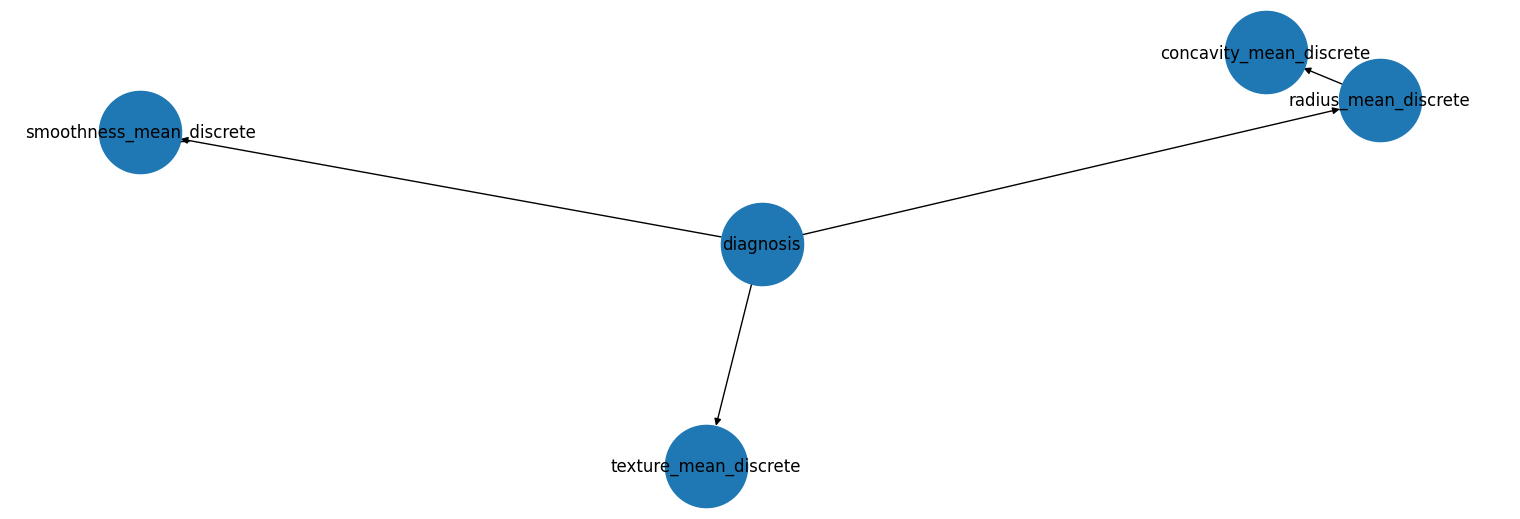

In [ ]:
plt.figure(figsize=(15, 5))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=3500)
plt.show()